## 0. Setup — carga única del dataset

Todas las librerías y la carga del CSV se hacen aquí una sola vez. Los sellos siguientes reutilizan el mismo `df`.

En Google Colab: subir `cafe_cordillera_dataset.csv` al panel de archivos (icono de carpeta a la izquierda) antes de ejecutar, o descomentar el bloque `files.upload()`.

In [1]:
# =============================================================
# SETUP GLOBAL - Librerias y carga del dataset
# =============================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

# --- Colab: descomentar para subir el archivo manualmente ---
# from google.colab import files; files.upload()

DATA_PATH = None
for _p in ["cafe_cordillera_dataset.csv",
           "../cafe_cordillera_dataset.csv",
           "/content/cafe_cordillera_dataset.csv",
           "/content/drive/MyDrive/cafe_cordillera_dataset.csv"]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontro cafe_cordillera_dataset.csv. "
        "Subalo al entorno o ajuste DATA_PATH manualmente."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["fecha"])
df["monto"] = df["precio_unitario"] * df["unidades"]

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Pedidos unicos: {df['id_pedido'].nunique():,} | Clientes: {df['id_cliente'].nunique():,}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Sucursales: {', '.join(sorted(df['sucursal'].unique()))}")
print()
print(df.head(3).to_string(index=False))

Archivo: cafe_cordillera_dataset.csv
Filas: 11,983 | Columnas: 16
Pedidos unicos: 7,731 | Clientes: 2,600
Rango de fechas: 2026-03-02 a 2026-05-31
Sucursales: Cartago, Escazu, Heredia, San Pedro

 id_transaccion  id_pedido  id_cliente      fecha  hora sucursal producto   categoria  precio_unitario  unidades  medio_pago    clima  promocion_activa promocion_tipo  calificacion_satisfaccion  monto
              1       2033         697 2026-03-02     6  Cartago Limonada bebida_fria             1284         1     tarjeta lluvioso                 0            NaN                        NaN   1284
              2       2033         697 2026-03-02     6  Cartago  Galleta      postre              841         1 sinpe_movil lluvioso                 0            NaN                        NaN    841
              3       2033         697 2026-03-02     6  Cartago   Frappe bebida_fria             1785         1 sinpe_movil lluvioso                 0            NaN                        NaN   1785


---

# Sello 4 — Distribuciones

### ¿Cuántos clientes puede esperar una sucursal en una hora dada?

**Pregunta de negocio del sello:** modelar la llegada de pedidos por hora para dimensionar personal e inventario.

> Método: conteo de pedidos por celda `sucursal × fecha × hora`, índice de dispersión (var/media) para elegir entre Poisson y Binomial, y prueba chi-cuadrado de bondad de ajuste en las 56 celdas.

Celdas (sucursal x fecha x hora): 5096
Pedidos en la malla: 7731 | pedidos únicos en el dataset: 7731

GLOBAL   media=1.517  varianza=1.978  indice=1.304
POR CELDA (sucursal x hora)  indice medio=0.989

Detalle San Pedro:
        lam  varianza   n  indice_dispersion
hora                                        
6     0.879     0.796  91              0.906
7     2.747     2.747  91              1.000
8     2.352     1.808  91              0.769
9     2.495     2.831  91              1.135
10    0.769     0.713  91              0.927
11    0.615     0.617  91              1.003
12    1.505     2.164  91              1.437
13    1.374     1.370  91              0.997
14    0.813     0.642  91              0.790
15    0.615     0.817  91              1.328
16    1.912     1.948  91              1.019
17    1.967     2.166  91              1.101
18    2.374     1.970  91              0.830
19    0.868     0.649  91              0.748

Bondad de ajuste en 56 celdas -> rechazan H0 al 5%: 8
(Co

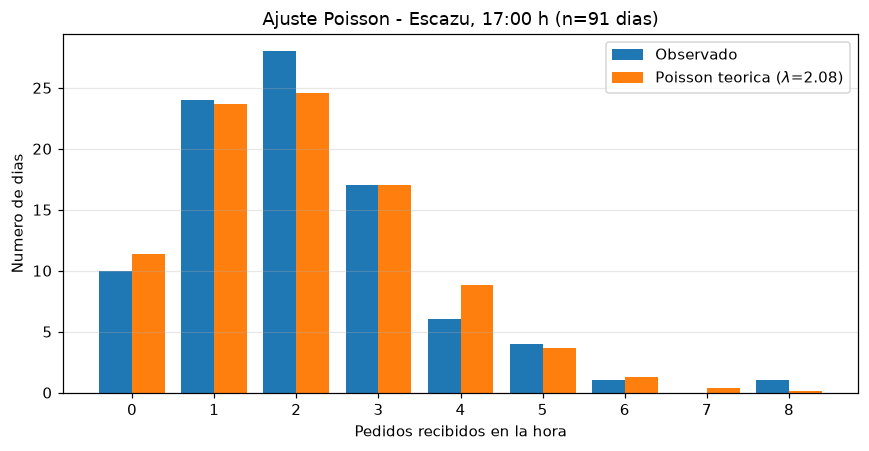

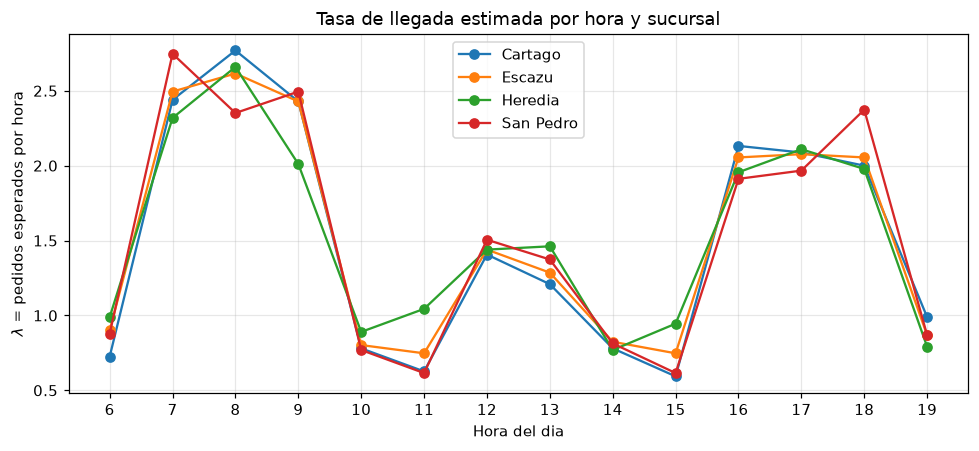


Lambda por hora y sucursal:
sucursal  Cartago  Escazu  Heredia  San Pedro
hora                                         
6            0.73    0.90     0.99       0.88
7            2.44    2.49     2.32       2.75
8            2.77    2.62     2.66       2.35
9            2.43    2.43     2.01       2.49
10           0.78    0.80     0.89       0.77
11           0.63    0.75     1.04       0.62
12           1.41    1.44     1.44       1.51
13           1.21    1.29     1.46       1.37
14           0.78    0.82     0.77       0.81
15           0.59    0.75     0.95       0.62
16           2.13    2.05     1.96       1.91
17           2.09    2.08     2.11       1.97
18           2.00    2.05     1.98       2.37
19           0.99    0.87     0.79       0.87

Pronostico Escazu 17:00 con lambda=2.08:
  P(0 pedidos) = 0.1253
  P(N <= 2)    = 0.6559
  P(N >= 5)    = 0.0599
  Percentil 95 = 5 pedidos


In [2]:
# =============================================================
# SELLO 4 - DISTRIBUCIONES (Poisson)
# =============================================================
# -------------------------------------------------------------
# 1. Unidad de análisis: PEDIDOS (no transacciones).
#    Un cliente que llega genera 1 id_pedido con varias líneas.
#    Se construye la malla completa sucursal x fecha x hora para
#    NO perder las horas con 0 pedidos (si no, se sesga lambda).
# -------------------------------------------------------------
pedidos = df.drop_duplicates("id_pedido")[["id_pedido", "fecha", "hora", "sucursal"]]

malla = pd.MultiIndex.from_product(
    [sorted(df["sucursal"].unique()),
     sorted(df["fecha"].unique()),
     sorted(df["hora"].unique())],
    names=["sucursal", "fecha", "hora"]
)
llegadas = (pedidos.groupby(["sucursal", "fecha", "hora"]).size()
            .reindex(malla, fill_value=0)
            .reset_index(name="pedidos"))

print("Celdas (sucursal x fecha x hora):", len(llegadas))
print("Pedidos en la malla:", llegadas["pedidos"].sum(),
      "| pedidos únicos en el dataset:", df["id_pedido"].nunique())

# -------------------------------------------------------------
# 2. ¿Poisson o Binomial? Criterio: índice de dispersión = var/media.
#    Poisson exige var ≈ media (índice ≈ 1).
# -------------------------------------------------------------
media_g = llegadas["pedidos"].mean()
var_g = llegadas["pedidos"].var(ddof=1)
print(f"\nGLOBAL   media={media_g:.3f}  varianza={var_g:.3f}  indice={var_g/media_g:.3f}")

disp = llegadas.groupby(["sucursal", "hora"])["pedidos"].agg(lam="mean", varianza="var", n="size")
disp["indice_dispersion"] = disp["varianza"] / disp["lam"]
print(f"POR CELDA (sucursal x hora)  indice medio={disp['indice_dispersion'].mean():.3f}")
print("\nDetalle San Pedro:")
print(disp.loc["San Pedro"].round(3))

# -------------------------------------------------------------
# 3. Prueba formal de bondad de ajuste (chi-cuadrado) contra Poisson.
#    Se agrupan clases hasta esperada >= 5. gl = k_bins - 1 - 1
#    (se resta 1 extra porque lambda se estimó de los datos).
# -------------------------------------------------------------
def gof_poisson(x, min_esp=5):
    x = np.asarray(x, dtype=int)
    n, lam, kmax = len(x), x.mean(), int(x.max())
    obs = np.bincount(x, minlength=kmax + 1).astype(float)
    esp = stats.poisson.pmf(np.arange(kmax + 1), lam) * n
    esp[-1] += (1 - stats.poisson.cdf(kmax, lam)) * n   # cola superior
    bins, o, e, k0 = [], 0.0, 0.0, 0
    for k in range(kmax + 1):
        o += obs[k]; e += esp[k]
        if e >= min_esp:
            bins.append([k0, k, o, e]); k0, o, e = k + 1, 0.0, 0.0
    if o > 0 or e > 0:
        if bins:
            bins[-1][1] = kmax; bins[-1][2] += o; bins[-1][3] += e
        else:
            bins.append([k0, kmax, o, e])
    b = pd.DataFrame(bins, columns=["k_min", "k_max", "obs", "esp"])
    chi2 = ((b["obs"] - b["esp"]) ** 2 / b["esp"]).sum()
    gl = len(b) - 2
    p = 1 - stats.chi2.cdf(chi2, gl) if gl > 0 else np.nan
    return lam, chi2, gl, p, b

res = []
for (s, h), g in llegadas.groupby(["sucursal", "hora"]):
    lam, chi2, gl, p, _ = gof_poisson(g["pedidos"].values)
    res.append({"sucursal": s, "hora": h, "lambda": lam, "chi2": chi2, "gl": gl, "p_value": p})
res = pd.DataFrame(res)

print(f"\nBondad de ajuste en {len(res)} celdas -> rechazan H0 al 5%: {(res['p_value']<0.05).sum()}")
print("(Con 56 pruebas al 5% se esperan ~3 rechazos solo por azar)")
print(res.sort_values("p_value").head(5).round(4).to_string(index=False))

# -------------------------------------------------------------
# 4. Celda foco para graficar el ajuste
# -------------------------------------------------------------
SUC, HORA = "Escazu", 17
foco = llegadas[(llegadas["sucursal"] == SUC) & (llegadas["hora"] == HORA)]["pedidos"].values
lam, chi2, gl, p, tabla = gof_poisson(foco)
print(f"\nCELDA FOCO {SUC} {HORA}:00 -> lambda={lam:.3f}  chi2={chi2:.3f}  gl={gl}  p={p:.4f}")
print(tabla.round(2).to_string(index=False))

k = np.arange(0, foco.max() + 1)
obs_frec = np.bincount(foco, minlength=len(k))
esp_frec = stats.poisson.pmf(k, lam) * len(foco)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(k - 0.2, obs_frec, width=0.4, label="Observado")
ax.bar(k + 0.2, esp_frec, width=0.4, label=f"Poisson teorica ($\\lambda$={lam:.2f})")
ax.set_xlabel("Pedidos recibidos en la hora")
ax.set_ylabel("Numero de dias")
ax.set_title(f"Ajuste Poisson - {SUC}, {HORA}:00 h (n={len(foco)} dias)")
ax.set_xticks(k); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# 5. Perfil de demanda: lambda por hora y sucursal
# -------------------------------------------------------------
lam_hora = llegadas.groupby(["hora", "sucursal"])["pedidos"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4.2))
for s in lam_hora.columns:
    ax.plot(lam_hora.index, lam_hora[s], marker="o", label=s)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("$\\lambda$ = pedidos esperados por hora")
ax.set_title("Tasa de llegada estimada por hora y sucursal")
ax.set_xticks(lam_hora.index); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nLambda por hora y sucursal:")
print(lam_hora.round(2))

# -------------------------------------------------------------
# 6. Uso operativo del modelo
# -------------------------------------------------------------
print(f"\nPronostico {SUC} {HORA}:00 con lambda={lam:.2f}:")
print(f"  P(0 pedidos) = {stats.poisson.pmf(0, lam):.4f}")
print(f"  P(N <= 2)    = {stats.poisson.cdf(2, lam):.4f}")
print(f"  P(N >= 5)    = {1 - stats.poisson.cdf(4, lam):.4f}")
print(f"  Percentil 95 = {stats.poisson.ppf(0.95, lam):.0f} pedidos")

---

# Sello 5 — Muestreo y sesgos

### ¿La encuesta la llenan solo los clientes contentos?

**Pregunta de negocio del sello:** ¿la calificación de satisfacción que tenemos representa a todos los clientes?

> Método: cuantificación de datos faltantes, chi-cuadrado de independencia entre responder y cada variable observable, t-test de Welch sobre el monto, y análisis de sensibilidad del sesgo de no respuesta.

Faltantes en calificacion_satisfaccion: 8534 de 11983 (71.22%)
Tasa de respuesta global: 28.78%
Muestra efectiva: n=3449

Perfil de respondientes vs no respondientes:
        variable  tasa_min  tasa_max  brecha_pp    chi2  gl  p_value
            hora    0.2451    0.3401     9.5025 19.4570  13   0.1096
        sucursal    0.2746    0.2954     2.0839  4.0177   3   0.2596
           clima    0.2781    0.2931     1.5032  2.2114   2   0.3310
promocion_activa    0.2851    0.2892     0.4119  0.1995   1   0.6551
       categoria    0.2833    0.2927     0.9384  1.1419   3   0.7670
      dia_semana    0.2769    0.2971     2.0170  2.4093   6   0.8785
      medio_pago    0.2873    0.2883     0.0948  0.0098   2   0.9951

Monto medio -> respondio: 2,269 | no respondio: 2,285
Welch t=-0.648, p=0.5170


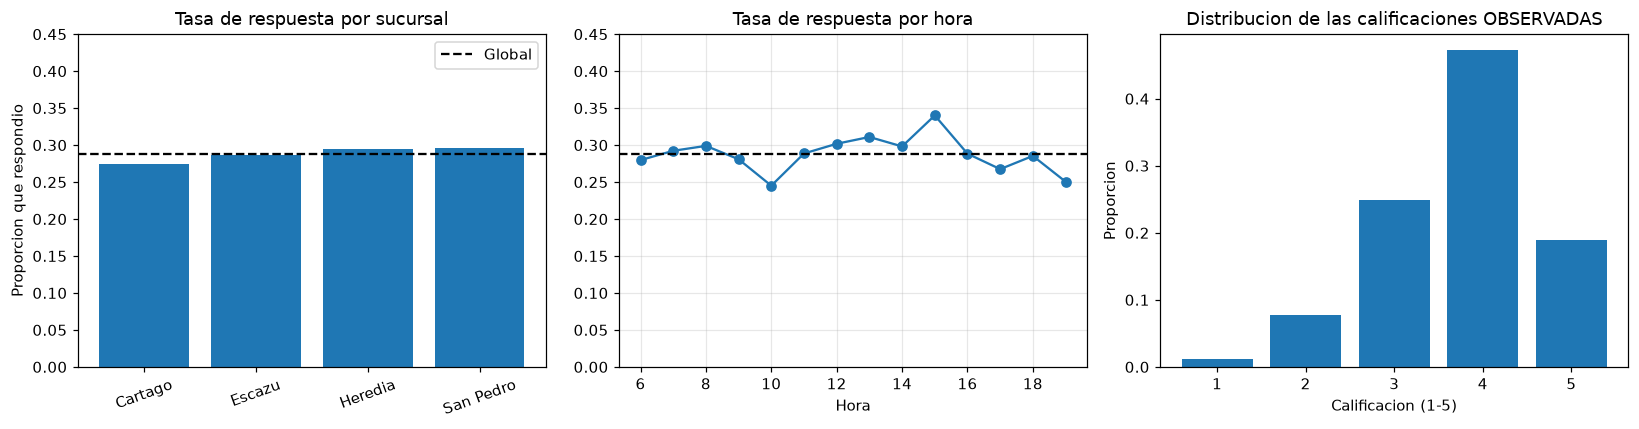


Distribucion observada de calificaciones:
calificacion_satisfaccion
1.0    0.0116
2.0    0.0768
3.0    0.2491
4.0    0.4726
5.0    0.1899
Name: proportion, dtype: float64

Media observada de satisfaccion = 3.752 (n=3449)
Escenarios si los no respondientes calificaran mas bajo:
 brecha_no_respondientes  media_real_estimada  sesgo_de_la_media_obs
                     0.0                3.752                  0.000
                    -0.5                3.396                  0.356
                    -1.0                3.040                  0.712
                    -1.5                2.684                  1.068


In [3]:
# =============================================================
# SELLO 5 - MUESTREO Y SESGOS
# =============================================================
df["respondio"] = df["calificacion_satisfaccion"].notna()
df["dia_semana"] = df["fecha"].dt.dayofweek

# -------------------------------------------------------------
# 1. Magnitud del problema
# -------------------------------------------------------------
n_tot = len(df)
n_falt = int(df["calificacion_satisfaccion"].isna().sum())
print(f"Faltantes en calificacion_satisfaccion: {n_falt} de {n_tot} ({n_falt/n_tot:.2%})")
print(f"Tasa de respuesta global: {df['respondio'].mean():.2%}")
print(f"Muestra efectiva: n={int(df['respondio'].sum())}\n")

# -------------------------------------------------------------
# 2. ¿Quién responde vs. quién no?
#    Chi-cuadrado de independencia entre cada variable observable
#    y el hecho de haber respondido. H0: responder es independiente
#    de esa variable (es decir, no hay sesgo detectable en ella).
# -------------------------------------------------------------
filas = []
for v in ["sucursal", "clima", "categoria", "promocion_activa",
          "medio_pago", "hora", "dia_semana"]:
    tabla = pd.crosstab(df[v], df["respondio"])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    tasa = df.groupby(v)["respondio"].mean()
    filas.append({"variable": v,
                  "tasa_min": tasa.min(), "tasa_max": tasa.max(),
                  "brecha_pp": (tasa.max() - tasa.min()) * 100,
                  "chi2": chi2, "gl": gl, "p_value": p})

comparacion = pd.DataFrame(filas).sort_values("p_value")
print("Perfil de respondientes vs no respondientes:")
print(comparacion.round(4).to_string(index=False))

# Variable continua: ¿gastan distinto los que responden?
a = df.loc[df["respondio"], "monto"]
b = df.loc[~df["respondio"], "monto"]
t_st, p_m = stats.ttest_ind(a, b, equal_var=False)
print(f"\nMonto medio -> respondio: {a.mean():,.0f} | no respondio: {b.mean():,.0f}")
print(f"Welch t={t_st:.3f}, p={p_m:.4f}")

# -------------------------------------------------------------
# 3. Gráficos
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tasa_suc = df.groupby("sucursal")["respondio"].mean()
axes[0].bar(tasa_suc.index, tasa_suc.values)
axes[0].axhline(df["respondio"].mean(), ls="--", color="black", label="Global")
axes[0].set_title("Tasa de respuesta por sucursal")
axes[0].set_ylabel("Proporcion que respondio"); axes[0].set_ylim(0, 0.45)
axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)

tasa_hora = df.groupby("hora")["respondio"].mean()
axes[1].plot(tasa_hora.index, tasa_hora.values, marker="o")
axes[1].axhline(df["respondio"].mean(), ls="--", color="black")
axes[1].set_title("Tasa de respuesta por hora")
axes[1].set_xlabel("Hora"); axes[1].set_ylim(0, 0.45); axes[1].grid(alpha=.3)

dist = df["calificacion_satisfaccion"].value_counts(normalize=True).sort_index()
axes[2].bar(dist.index.astype(int), dist.values)
axes[2].set_title("Distribucion de las calificaciones OBSERVADAS")
axes[2].set_xlabel("Calificacion (1-5)"); axes[2].set_ylabel("Proporcion")

plt.tight_layout(); plt.show()

print("\nDistribucion observada de calificaciones:")
print(dist.round(4))

# -------------------------------------------------------------
# 4. Análisis de sensibilidad: cuánto se equivoca la gerencia si
#    asume que los no respondientes son iguales a los respondientes.
#    media_real = r * media_obs + (1-r) * (media_obs + brecha)
# -------------------------------------------------------------
m_obs = df["calificacion_satisfaccion"].mean()
r = df["respondio"].mean()

esc = pd.DataFrame({"brecha_no_respondientes": [0.0, -0.5, -1.0, -1.5]})
esc["media_real_estimada"] = r * m_obs + (1 - r) * (m_obs + esc["brecha_no_respondientes"])
esc["sesgo_de_la_media_obs"] = m_obs - esc["media_real_estimada"]

print(f"\nMedia observada de satisfaccion = {m_obs:.3f} (n={int(df['respondio'].sum())})")
print("Escenarios si los no respondientes calificaran mas bajo:")
print(esc.round(3).to_string(index=False))

---

# Sello 6 — Intervalos de confianza

### ¿Cuál es el ticket promedio real de Café Cordillera, con qué margen de error?

**Pregunta de negocio del sello:** estimar el ticket promedio con un rango, no con un punto.

> Método: IC del 95 % por t de Student sobre el ticket agregado por `id_pedido`, verificación por bootstrap (5,000 remuestreos) y desagregación por sucursal con forest plot.

count     7731.0
mean      3534.3
std       2302.5
min       1062.0
25%       1649.0
50%       3029.0
75%       4638.0
max      18409.0
Name: ticket, dtype: float64
Asimetria (skew) = 1.468

IC 95% GLOBAL del ticket
  media  = 3,534.3 CRC
  IC 95% = [3,483.0 ; 3,585.6]
  margen = +/- 51.3 CRC  (1.45% de la media)

IC 95% bootstrap (5,000 remuestreos): [3,481.7 ; 3,585.2]
Coincidencia con el IC t -> el uso del TCL es apropiado.

IC 95% del ticket por sucursal:
 sucursal    n  media  desv_est   ee  lim_inf  lim_sup  margen
  Cartago 1908 3468.0    2261.4 51.8   3366.4   3569.5   101.5
   Escazu 1942 3756.7    2410.8 54.7   3649.4   3864.0   107.3
  Heredia 1944 3453.2    2272.9 51.6   3352.1   3554.3   101.1
San Pedro 1937 3458.1    2248.0 51.1   3357.9   3558.3   100.2

IC 95% del monto por linea: 2,280.2 [2,257.6 ; 2,302.8]  (n=11983)


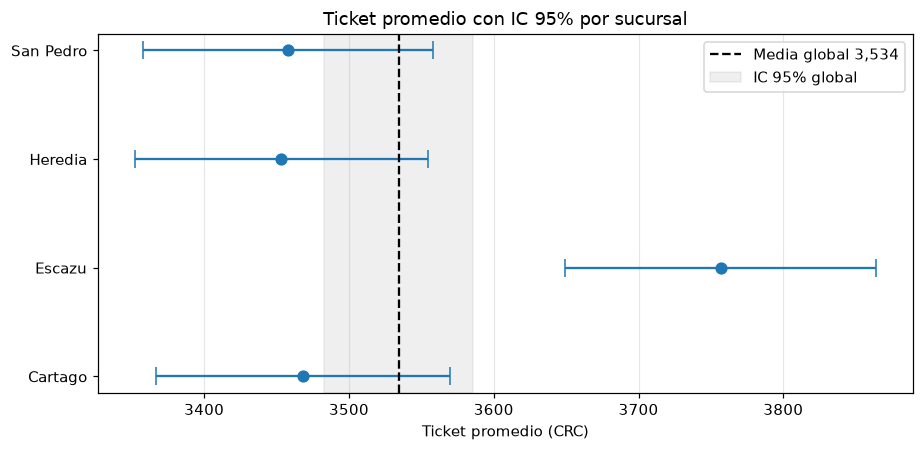


Traslape de intervalos entre sucursales:
  Cartago    vs Escazu     -> NO se traslapan
  Cartago    vs Heredia    -> se traslapan
  Cartago    vs San Pedro  -> se traslapan
  Escazu     vs Heredia    -> NO se traslapan
  Escazu     vs San Pedro  -> NO se traslapan
  Heredia    vs San Pedro  -> se traslapan


In [4]:
# =============================================================
# SELLO 6 - INTERVALOS DE CONFIANZA
# =============================================================
# Definición: ticket = gasto total de UN pedido = suma de
# (precio_unitario * unidades) de todas sus líneas.
# -------------------------------------------------------------
ticket = df.groupby("id_pedido")["monto"].sum().rename("ticket")
suc_pedido = df.drop_duplicates("id_pedido").set_index("id_pedido")["sucursal"]
tk = pd.concat([ticket, suc_pedido], axis=1)

print(tk["ticket"].describe().round(1))
print(f"Asimetria (skew) = {stats.skew(tk['ticket']):.3f}")

# -------------------------------------------------------------
# 1. IC de la media por t de Student.
#    Justificación: sigma poblacional desconocida -> t, no z.
#    La distribución del ticket es asimétrica a la derecha, pero
#    n = 7,731 hace que el TCL garantice normalidad de la MEDIA
#    muestral. Con gl > 5000, t practicamente coincide con z.
# -------------------------------------------------------------
def ic_media(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    ee = x.std(ddof=1) / np.sqrt(n)          # error estandar
    t = stats.t.ppf(1 - (1 - conf) / 2, n - 1)
    return {"n": n, "media": m, "desv_est": x.std(ddof=1), "ee": ee,
            "lim_inf": m - t * ee, "lim_sup": m + t * ee, "margen": t * ee}

g = ic_media(tk["ticket"])
print(f"\nIC 95% GLOBAL del ticket")
print(f"  media  = {g['media']:,.1f} CRC")
print(f"  IC 95% = [{g['lim_inf']:,.1f} ; {g['lim_sup']:,.1f}]")
print(f"  margen = +/- {g['margen']:,.1f} CRC  ({g['margen']/g['media']:.2%} de la media)")

# -------------------------------------------------------------
# 2. Verificación con bootstrap (no asume normalidad).
#    Si coincide con el IC t, el supuesto del TCL se sostiene.
# -------------------------------------------------------------
rng = np.random.default_rng(42)
boot = rng.choice(tk["ticket"].values, size=(5000, len(tk)), replace=True).mean(axis=1)
lo_b, hi_b = np.percentile(boot, [2.5, 97.5])
print(f"\nIC 95% bootstrap (5,000 remuestreos): [{lo_b:,.1f} ; {hi_b:,.1f}]")
print("Coincidencia con el IC t -> el uso del TCL es apropiado.")

# -------------------------------------------------------------
# 3. IC por sucursal
# -------------------------------------------------------------
por_suc = pd.DataFrame([{"sucursal": s, **ic_media(gg["ticket"])}
                        for s, gg in tk.groupby("sucursal")])
print("\nIC 95% del ticket por sucursal:")
print(por_suc.round(1).to_string(index=False))

# IC del monto por linea de transaccion (metrica secundaria)
lin = ic_media(df["monto"])
print(f"\nIC 95% del monto por linea: {lin['media']:,.1f} "
      f"[{lin['lim_inf']:,.1f} ; {lin['lim_sup']:,.1f}]  (n={lin['n']})")

# -------------------------------------------------------------
# 4. Gráfico tipo forest plot
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.errorbar(por_suc["media"], por_suc["sucursal"],
            xerr=por_suc["margen"], fmt="o", capsize=6, markersize=7)
ax.axvline(g["media"], ls="--", color="black", label=f"Media global {g['media']:,.0f}")
ax.axvspan(g["lim_inf"], g["lim_sup"], alpha=.12, color="gray", label="IC 95% global")
ax.set_xlabel("Ticket promedio (CRC)")
ax.set_title("Ticket promedio con IC 95% por sucursal")
ax.legend(); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# 5. ¿Se traslapan los intervalos? (lectura preliminar; la prueba
#     formal corresponde al Sello 7)
# -------------------------------------------------------------
print("\nTraslape de intervalos entre sucursales:")
for i in range(len(por_suc)):
    for j in range(i + 1, len(por_suc)):
        a_, b_ = por_suc.iloc[i], por_suc.iloc[j]
        solapa = not (a_["lim_sup"] < b_["lim_inf"] or b_["lim_sup"] < a_["lim_inf"])
        print(f"  {a_['sucursal']:<10} vs {b_['sucursal']:<10} -> "
              f"{'se traslapan' if solapa else 'NO se traslapan'}")